In [2]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# res='1km';t_res='5min';Np_str='1e6'

# dx = 1km; Np = 50M
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'


# dx = 250 m
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [3]:
#LOADING IN H5 VARIABLES
file_path = dir + 'Variable_Calculation/' + f'theta_e_{res}_{t_res}.h5'
th_e_ds = xr.open_dataset(file_path, phony_dims='sort',engine='h5netcdf')  # or engine='netcdf4'
th_e_ds = th_e_ds.rename({
    'phony_dim_0': 'time',
    'phony_dim_1': 'zh',
    'phony_dim_2': 'yh',
    'phony_dim_3': 'xh'
})

file_path = dir + 'Variable_Calculation/' + '2D_Moisture_Convergence' + f'_{res}_{t_res}' + '.h5'
hmc_ds = xr.open_dataset(file_path, phony_dims='sort',engine='h5netcdf')  # or engine='netcdf4'
hmc_ds = hmc_ds.rename({
    'phony_dim_0': 'time',
    'phony_dim_1': 'zh',
    'phony_dim_2': 'yh',
    'phony_dim_3': 'xh'
})

In [4]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [5]:
#PROFILES AT SINGLE TIME

def CloudyPlot(t,var,var_name):
    
    # var_z = np.mean(var,axis=(1,2))
    var_z = np.mean(var,axis=(0,2,3))
    mask1 = (data['winterp'].isel(time=t) >= 0.5) & ((data['qc'].isel(time=t) + data['qi'].isel(time=t)) >= 1e-6)
    print(np.any(mask1))
    # masked_profile1 = np.ma.masked_where(~mask1, var)
    masked_profile1 = np.where(~mask1, np.nan, var)
    # var_cloudy= np.nanmean(masked_profile1, axis=(1, 2))
    var_cloudy= np.nanmean(masked_profile1, axis=(0, 2, 3))
    print('done')
    
    #########################

    if var_name in ["qv","qc","HMC"]:
        var_z*=1000
        var_cloudy*=1000

    
    
    # New Subplots for Contour Plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    #First plot
    axes[0].plot(var_z,data['zh'])
    axes[0].axvline(0,color='black')
    axes[0].set_title('var(z) Horizontal Average for Eulerian Data Everywhere',fontsize=8)
    
    
    
    
    #Second plot
    axes[1].plot(var_cloudy,data['zh'])
    axes[1].axvline(0,color='black')
    axes[1].set_title(f'{var_name}(z) Horizontal Average for Eulerian Data (w ≥ 0.5) & (qc+qi ≥ 1e-6)',fontsize=8)
    
    
    apply_scientific_notation([axes[0],axes[1]])
    plt.suptitle(f'Horizontal Average of 2D {var_name} For Entire Domain vs Within Cloudy Updrafts (AT TIME {t})')
    # plt.tight_layout()

In [6]:
#PROFILES AT SINGLE TIME

def GeneralPlot(t,var,var_name):
    
    # var_z = np.mean(var,axis=(1,2))
    var_z = np.mean(var,axis=(0,2,3))
    mask1 = (data['winterp'].isel(time=t) >= 0.1) & ((data['qc'].isel(time=t) + data['qi'].isel(time=t)) < 1e-6)
    print(np.any(mask1))
    # masked_profile1 = np.ma.masked_where(~mask1, var)
    masked_profile1 = np.where(~mask1, np.nan, var)
    # var_cloudy= np.nanmean(masked_profile1, axis=(1, 2))
    var_cloudy= np.nanmean(masked_profile1, axis=(0, 2, 3))
    print('done')
    
    #########################
    
    
    # New Subplots for Contour Plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    if var_name in ["qv","qc","HMC"]:
        var_z*=1000
        var_cloudy*=1000
    
    #First plot
    axes[0].plot(var_z,data['zh'])
    axes[0].axvline(0,color='black')
    axes[0].set_title('var(z) Horizontal Average for Eulerian Data Everywhere',fontsize=8)
    
    #Second plot
    axes[1].plot(var_cloudy,data['zh'])
    axes[1].axvline(0,color='black')
    axes[1].set_title(f'{var_name}(z) Horizontal Average for Eulerian Data (w ≥ 0.1) & (qc+qi < 1e-6)',fontsize=8)
    
    
    apply_scientific_notation([axes[0],axes[1]])
    plt.suptitle(f'Horizontal Average of 2D {var_name} For Entire Domain vs Within General Updrafts (AT TIME {t})')
    # plt.tight_layout()

In [7]:
if t_res=='5min':
    T=int(np.ceil(345/5))
    t=slice(T,T+1)
if t_res=='1min':
    T=345
    t=slice(T,T+1)
    # t=slice(300,310)
print(T)

345


<xarray.DataArray ()>
array(True)
done
<xarray.DataArray ()>
array(True)
done


/tmp/ipykernel_228833/2605171024.py:12: RuntimeWarning: Mean of empty slice
  var_cloudy= np.nanmean(masked_profile1, axis=(0, 2, 3))


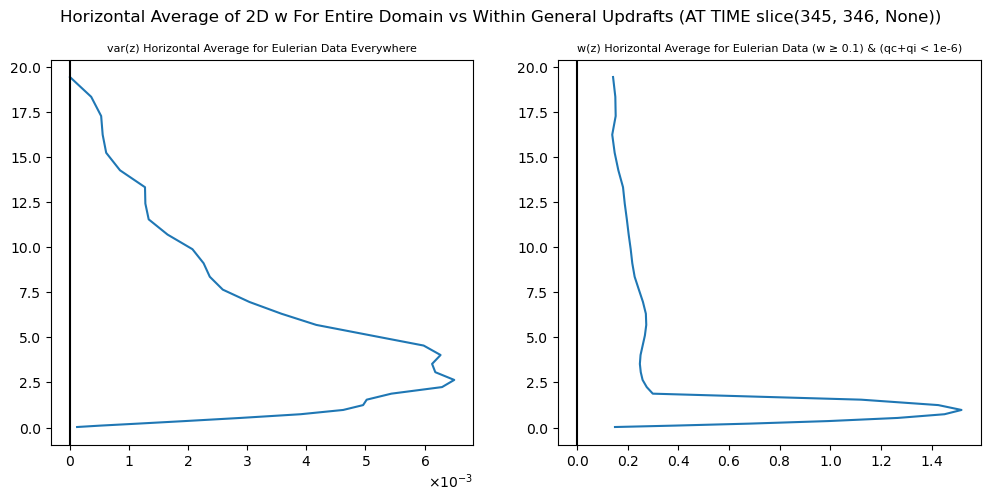

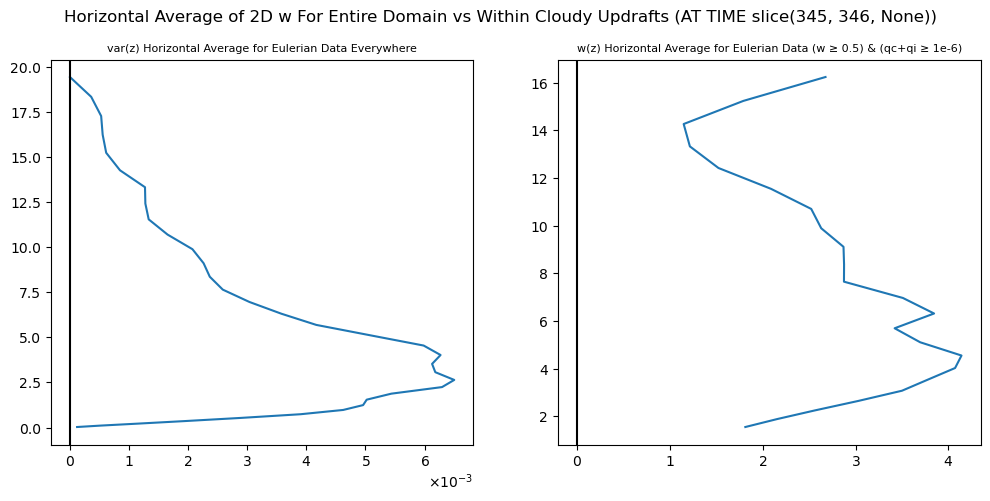

In [8]:
######################
#W

#READING BACK IN
w=data['winterp'].isel(time=t).data


GeneralPlot(t,w,"w")
CloudyPlot(t,w,"w")

<xarray.DataArray ()>
array(True)
done
<xarray.DataArray ()>
array(True)
done


/tmp/ipykernel_226780/2605171024.py:12: RuntimeWarning: Mean of empty slice
  var_cloudy= np.nanmean(masked_profile1, axis=(0, 2, 3))


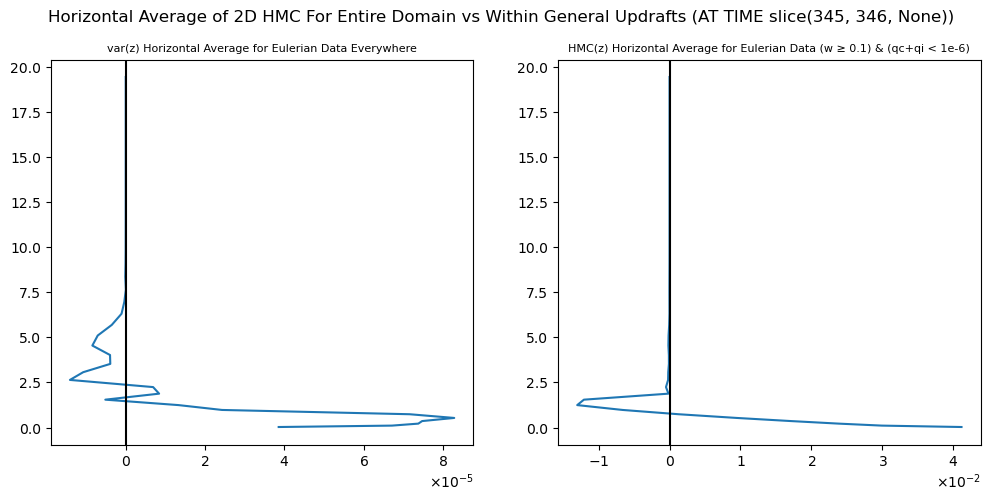

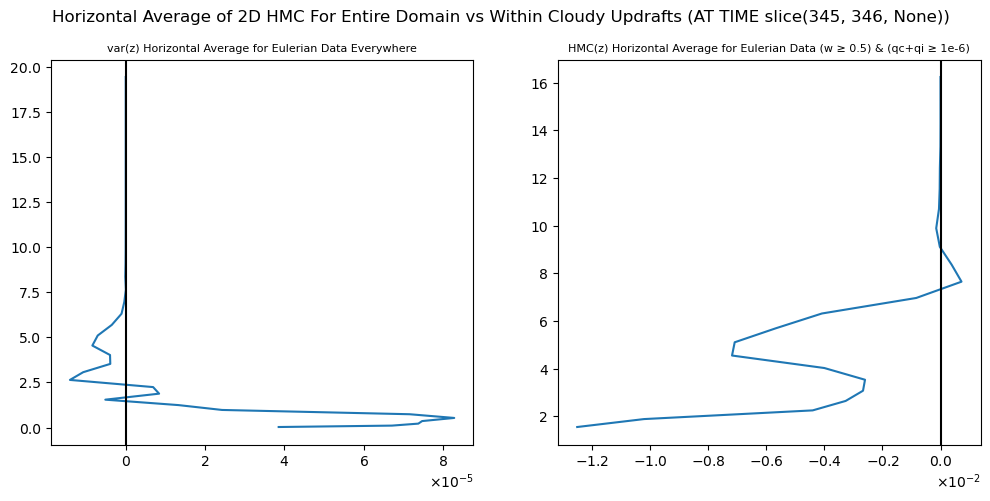

In [158]:
######################
#HMC

#READING BACK IN
HMC=hmc_ds['conv'].isel(time=t).data


GeneralPlot(t,HMC,"HMC")
CloudyPlot(t,HMC,"HMC")

In [ ]:
#######################################################

In [9]:
#A BUNCH OF PLOTS
#PROFILES AT SINGLE TIME
def CloudyPlot(t, var, var_name, ax):
    mask1 = (data['winterp'].isel(time=t) >= 0.5) & ((data['qc'].isel(time=t) + data['qi'].isel(time=t)) >= 1e-6)
    masked_profile1 = np.where(~mask1, np.nan, var)
    var_cloudy = np.nanmean(masked_profile1, axis=(0, 2, 3))

    if var_name in ["qv", "qc", "HMC"]:
        var_cloudy *= 1000  # convert to g/kg or g/m^3

    ax.plot(var_cloudy, data['zh'])
    ax.axvline(0, color='black')
    ax.set_title(f'{var_name} (t={t})', fontsize=8)
    ax.set_xlabel(var_name)
    ax.set_ylabel('Height (m)')

    apply_scientific_notation([ax])
    return ax

current t slice(345, 346, None)
current t slice(335, 336, None)
current t slice(340, 341, None)
current t slice(345, 346, None)
current t slice(350, 351, None)
current t slice(355, 356, None)
current t slice(360, 361, None)


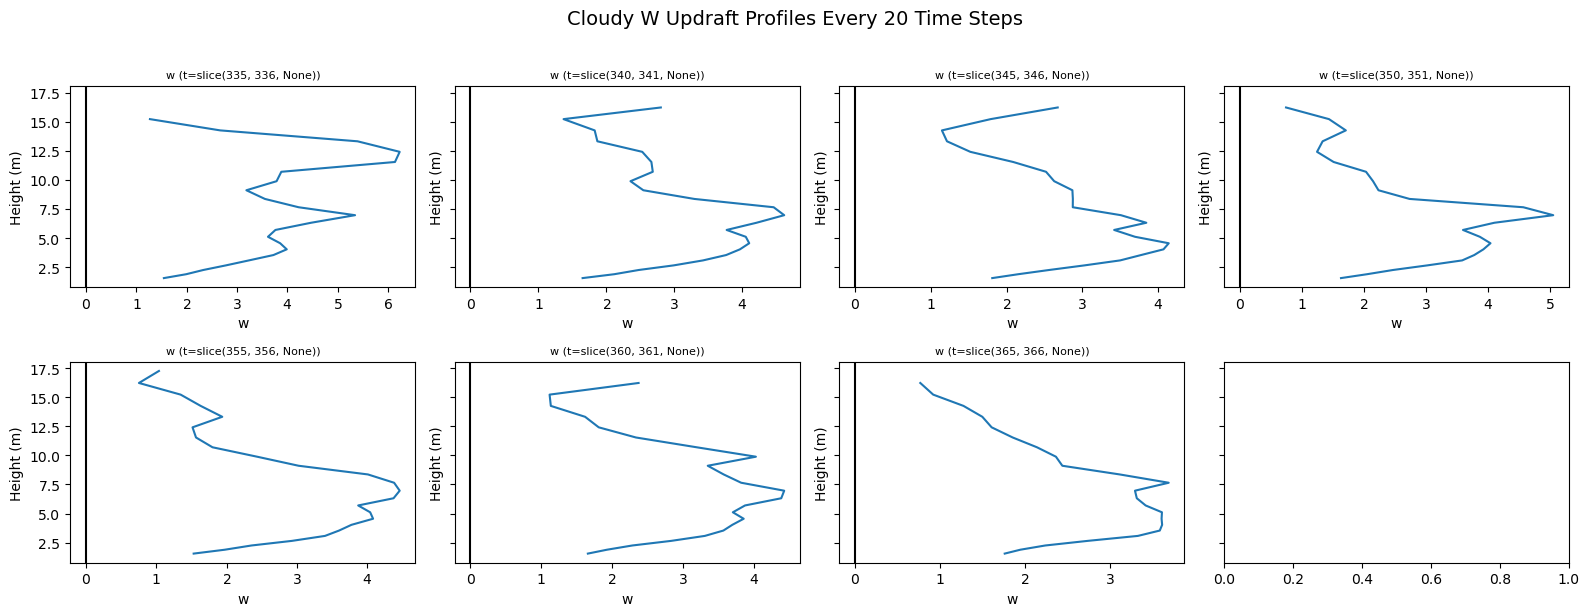

In [10]:
import warnings

# plot_dt=50
# t_indices = range(35, len(data['time']), plot_dt)

t_indices = range(335, 370, 5)
nplots = len(t_indices)
ncols = 4
nrows = int(np.ceil(nplots / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=True)
axs = axs.flatten()  # make 1D for easy indexing

var = data['winterp'].data  # or whichever 4D variable you want to analyze

for i, T in enumerate(t_indices):
    print(f"current t {t}")
    t=slice(T,T+1)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        CloudyPlot(t, var[t], "w", axs[i])

plt.suptitle("Cloudy W Updraft Profiles Every 20 Time Steps", fontsize=14, y=1.02)
plt.tight_layout()